# Reproducing Figure 1 and Table 2

This notebook regenerates the two main results of *Connecting the Dots* (SLT) from the per-utterance ASR scores:

* **Figure 1**: longitudinal WER for the standard and highest-error minority accent in each of the 8 evaluation sets, with the gap between them (one PNG per panel).
* **Table 2**: Mean Degradation (MD) for both accents, each accent's MD rank within its dataset, and a bootstrap test of whether the minority accent degrades more than the standard one.

**Inputs** (place in `data/`):

| File | Contents |
|---|---|
| `scores_asr.csv` | L2-Arctic, L1-Arctic, L2-Arctic Spontaneous, Speech Accent Archive, OpenSLR83 (and other datasets not used here) |
| `allstar_results_for_plotting_0314.csv` | ALLSTAR, one row per utterance with a `task` column (LPP, DHR, HT1, HT2) |

Both files have one row per (model, utterance) with `wer` and `cer` stored as fractions.
Model logos for the x-axis are read from `logos/`.

**Outputs** are written to `outputs/`: the 8 figure panels and `table2.csv`.

Requirements: `numpy pandas scipy matplotlib`. The full notebook runs in about a minute.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from scipy.stats import spearmanr
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

DATA_DIR = "data"
LOGO_DIR = "logos"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_BOOTSTRAP = 1000   # bootstrap resamples for the Table 2 significance test
SEED = 0

### Datasets and accent pairs

Each evaluation set is compared on one standard accent and one minority accent (the one with the highest average WER).
`arrow` controls whether Figure 1 marks the largest degradation for the minority accent (as in the published panels).

In [2]:
DATASETS = {
    # key in the data             title in figure / table          minority accent   standard accent     output file
    "L2-Arctic":             dict(title="L2-Arctic",             minority="Vietnamese",    standard="USA",              file="l2_arctic.png",                 arrow=True),
    "L2-Arctic Spontaneous": dict(title="L2-Arctic Spontaneous", minority="Korean",        standard="USA",              file="l2_arctic_spontaneous.png",     arrow=True),
    "SAA":                   dict(title="Speech Accent Archive", minority="Korean",        standard="English",          file="SAA.jpg",                       arrow=True),
    "Openslr83":             dict(title="OpenSLR83",             minority="Irish English", standard="Southern English", file="OpenSLR_83.png",                arrow=True),
    "ALLSTAR_LPP":           dict(title="ALLSTAR (Le Petit Prince)",             minority="VIE", standard="ENG", file="allstar_wer_plot_LPP.png", arrow=False),
    "ALLSTAR_DHR":           dict(title="ALLSTAR (Declaration of Human Rights)", minority="CCT", standard="ENG", file="allstar_wer_plot_DHR.png", arrow=False),
    "ALLSTAR_HT1":           dict(title="ALLSTAR (HINT Sentences 1)",            minority="RUN", standard="ENG", file="allstar_wer_plot_HT1.png", arrow=False),
    "ALLSTAR_HT2":           dict(title="ALLSTAR (HINT Sentences 2)",            minority="RUN", standard="ENG", file="allstar_wer_plot_HT2.png", arrow=False),
}

# How accent labels appear in the figures and table
ACCENT_NAMES = {
    "USA": "Mainstream US English",
    "English": "Mainstream US English",
    "ENG": "Mainstream US English",
    "Southern English": "Southern British English",
    "VIE": "Vietnamese English",
    "CCT": "Cantonese English",
    "RUN": "Runyankore English",
}
def accent_name(code):
    if code in ACCENT_NAMES:
        return ACCENT_NAMES[code]
    return code if code.endswith("English") else f"{code} English"

MODEL_LOGOS = {
    "Deepspeech": "mozilla.png",
    "WavLM Libri-100h": "microsoft.png",
    "Whisper Large v1": "openai.png",
    "Whisper Large v2": "openai.png",
    "Whisper Large v3": "openai.png",
    "MMS 1B All": "meta.png",
    "SeamlessM4T": "meta.png",
    "Omnilingual 7B": "meta.png",
    "OWSM 1.0 272M": "cmu.png",
    "OWSM 2.0 739M": "cmu.png",
    "OWSM 3.1 1B": "cmu.png",
    "OWSM 4.0 1B": "cmu.png",
    "Qwen2 Audio 7B": "qwen.png",
    "Qwen3 ASR 1.7B": "qwen.png",
    "Qwen3 Audio 14B": "qwen.png",
    "Canary Qwen 2.5B": "nvidia.png",
    "Google Chirp 3": "google.png",
}

## Load the scores

* ALLSTAR's four reading tasks are treated as separate datasets (`ALLSTAR_LPP`, ...).
* L2-Arctic has no native-English speakers, so the Mainstream US English (`USA`) utterances of L1-Arctic are added to it as the standard accent.
* Speech Accent Archive keeps only accents with more than 20 recordings (see the supplementary material).

In [3]:
COLUMNS = ["dataset", "model", "release_date", "sample_id", "native_language", "wer", "cer"]

scores = pd.read_csv(os.path.join(DATA_DIR, "scores_asr.csv"))
allstar = pd.read_csv(os.path.join(DATA_DIR, "allstar_results_for_plotting_0314.csv"))
allstar["dataset"] = "ALLSTAR_" + allstar["task"]

l1_arctic_muse = scores[(scores["dataset"] == "L1-Arctic") & (scores["native_language"] == "USA")]
l1_arctic_muse = l1_arctic_muse.assign(dataset="L2-Arctic")

# `source` records which file each row came from; the Figure 1 outlier filter depends on it
scores = pd.concat([scores[COLUMNS].assign(source="scores_asr"),
                    l1_arctic_muse[COLUMNS].assign(source="l1_arctic_reference"),
                    allstar[COLUMNS].assign(source="allstar")], ignore_index=True)
scores = scores[scores["dataset"].isin(DATASETS)]

# Speech Accent Archive: keep accents with more than 20 recordings
saa_counts = scores[(scores["dataset"] == "SAA") & (scores["model"] == "Whisper Large v1")]["native_language"].value_counts()
saa_keep = saa_counts[saa_counts > 20].index
scores = scores[(scores["dataset"] != "SAA") | scores["native_language"].isin(saa_keep)]

summary = scores.groupby("dataset").agg(models=("model", "nunique"), accents=("native_language", "nunique"), rows=("wer", "size"))
summary.loc[list(DATASETS)]

,models,accents,rows
dataset,,,
L2-Arctic,16,7,64076
L2-Arctic Spontaneous,16,7,367
SAA,16,12,9609
Openslr83,16,6,4894
ALLSTAR_LPP,16,22,122016
ALLSTAR_DHR,16,21,77632
ALLSTAR_HT1,16,22,251040
ALLSTAR_HT2,16,22,227680


In [4]:
def models_in_release_order(frame):
    # (model, release_date) pairs sorted by release date
    pairs = frame[["model", "release_date"]].drop_duplicates().sort_values("release_date")
    return pairs["model"].tolist(), pairs["release_date"].tolist()

## Figure 1

Top panel: mean WER per model for the minority accent, the standard accent (with a standard-error band) and, in grey, up to 10 other accents with the largest degradations.
Bottom panel: the gap (minority − standard) per model, its average, and the Spearman correlation between release order and gap size.

Outlier utterances are dropped for the plots, following the original analysis so the published panels are reproduced exactly:

* `scores_asr.csv` datasets: utterances with WER or CER above 100% are dropped.
* ALLSTAR: only WER above 100% is dropped. (Its CER column is above 100% for many utterances whose recording does not match the reference text, so a CER filter would remove ~30% of some accents.)
* The L1-Arctic reference utterances added to L2-Arctic are kept unfiltered, because the original analysis added them after this filter.
  Set `FILTER_L1_ARCTIC_REFERENCE = True` to filter them too; the L2-Arctic gap then moves from 17.3% (ρ = −0.60) to 18.7% (ρ = −0.85).

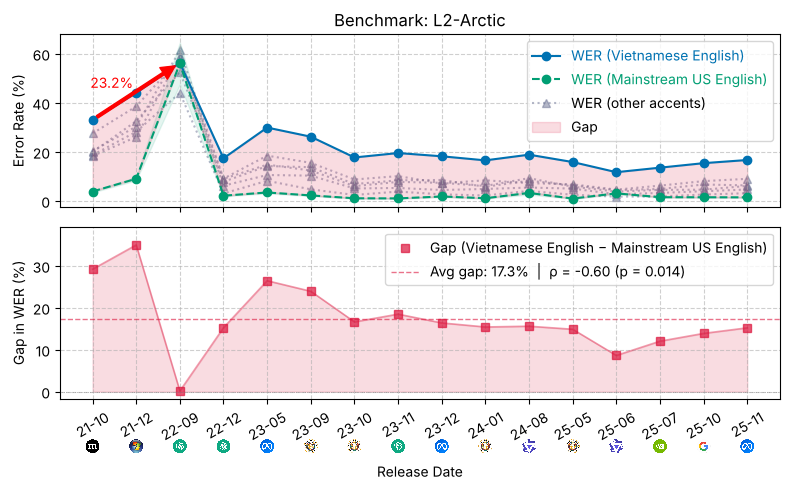

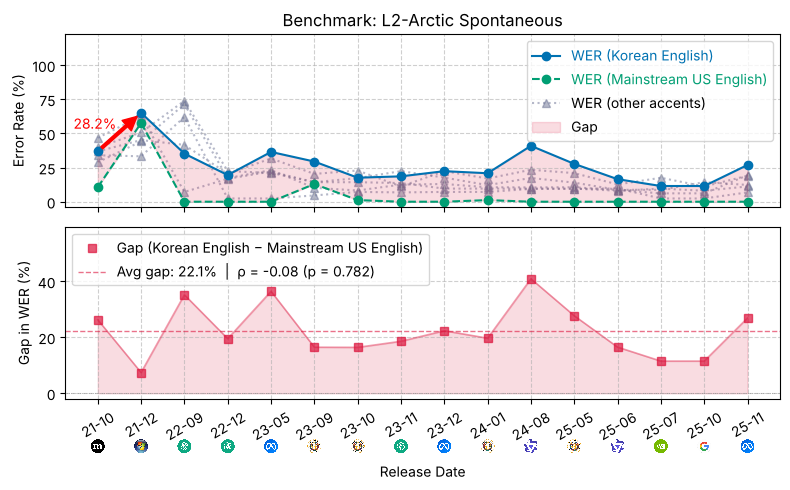

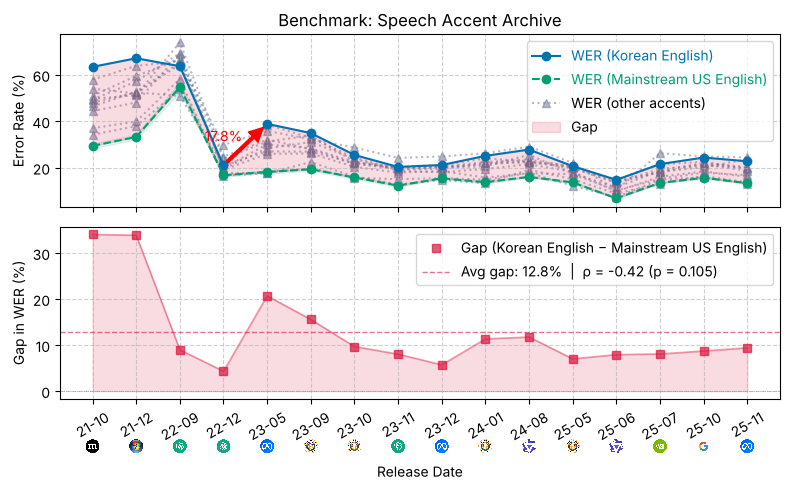

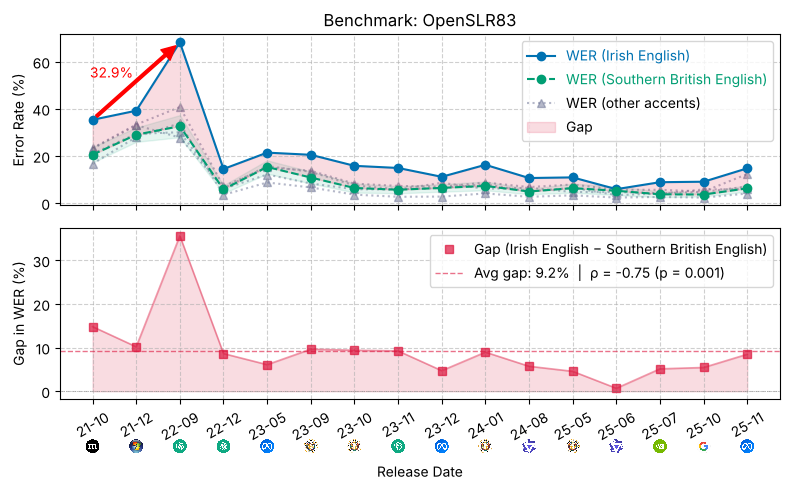

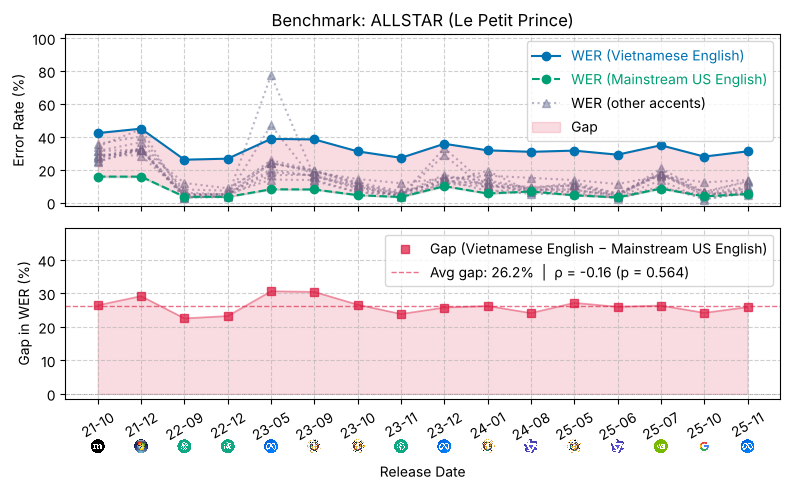

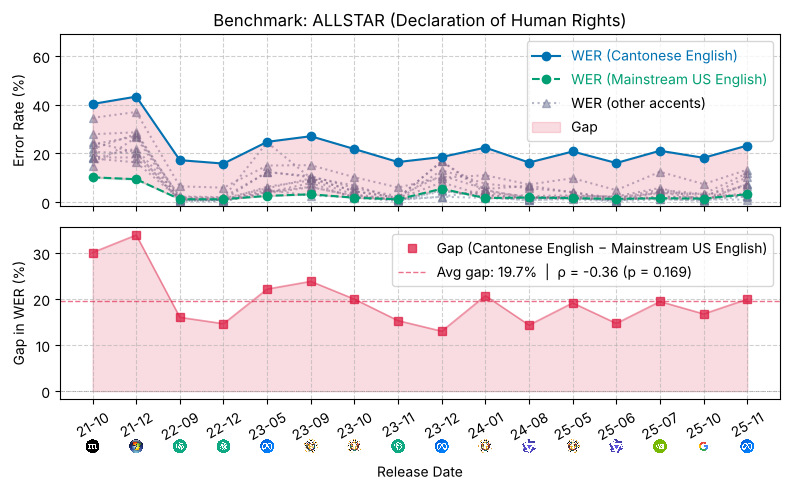

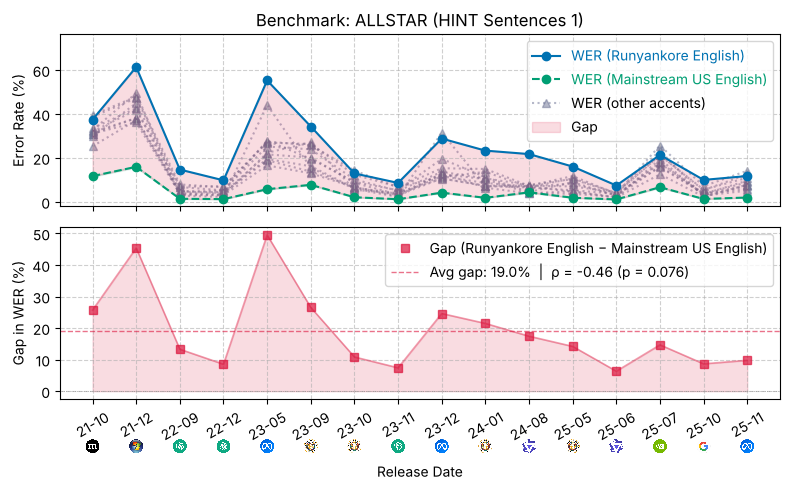

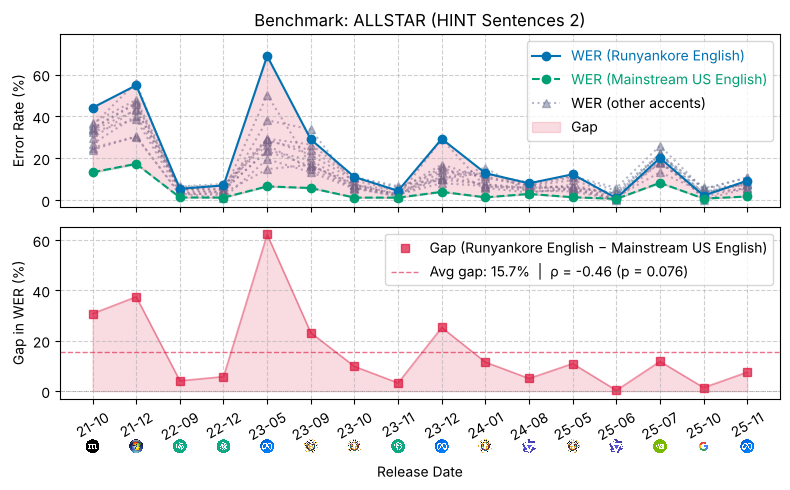

,dataset,avg_gap,spearman_rho,p_value
0,L2-Arctic,17.330,-0.600,0.014
1,L2-Arctic Spontaneous,22.096,-0.075,0.782
2,Speech Accent Archive,12.830,-0.421,0.105
3,OpenSLR83,9.208,-0.750,0.001
4,ALLSTAR (Le Petit Prince),26.167,-0.156,0.564
5,ALLSTAR (Declaration of Human Rights),19.652,-0.362,0.169
6,ALLSTAR (HINT Sentences 1),19.035,-0.456,0.076
7,ALLSTAR (HINT Sentences 2),15.669,-0.456,0.076


In [5]:
############## Plot style ##############
plt.style.use("seaborn-v0_8-colorblind")
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"] + ["#6C7394"]
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams["figure.dpi"] = 100     # inline display
plt.rcParams["savefig.dpi"] = 300    # saved panels

MINORITY_COLOR = colors[0]
STANDARD_COLOR = colors[1]
OTHER_ACCENTS_COLOR = colors[-1]
N_OTHER_ACCENTS = 10
XTICK_ROTATION = 30   # degrees; labels stay centred on their ticks (and logos)
FILTER_L1_ARCTIC_REFERENCE = False   # False reproduces the published L2-Arctic panel (see above)


def mean_and_sem(frame):
    # per-model mean and standard error of WER (in %), in release order
    out = (frame.groupby(["release_date", "model"])["wer"]
                .agg(["mean", "sem"]).reset_index().sort_values("release_date"))
    out[["mean", "sem"]] *= 100
    return out


def max_degradation(model_means):
    # largest increase in mean WER from an earlier model i to a later model j -> (i, j, size)
    best = (None, None, 0.0)
    for i in range(len(model_means)):
        for j in range(i + 1, len(model_means)):
            diff = model_means[j] - model_means[i]
            if diff > best[2]:
                best = (i, j, diff)
    return best


def place_legend_clear_of_data(ax, **legend_kwargs):
    # Put the legend in the top corner that needs the least headroom, then raise the
    # y-axis just enough that no data point sits underneath it.
    pts = np.vstack([l.get_xydata() for l in ax.get_lines() if len(l.get_xydata())])
    pts = pts[np.isfinite(pts).all(axis=1)]
    bottom, top = ax.get_ylim()
    best = None
    for loc in ("upper right", "upper left"):
        leg = ax.legend(loc=loc, **legend_kwargs)
        ax.figure.canvas.draw()
        bb = leg.get_window_extent().transformed(ax.transAxes.inverted())
        x0, x1 = [ax.transData.inverted().transform(ax.transAxes.transform((x, 0)))[0] for x in (bb.x0, bb.x1)]
        under = pts[(pts[:, 0] >= x0 - 0.3) & (pts[:, 0] <= x1 + 0.3), 1]
        ymax = under.max() if len(under) else bottom
        needed = bottom + (ymax - bottom) / max(bb.y0 - 0.04, 0.1)
        if best is None or needed < best[1]:
            best = (loc, needed)
    leg = ax.legend(loc=best[0], **legend_kwargs)
    ax.set_ylim(bottom, max(top, best[1]))
    return leg


def draw_degradation_arrow(ax, x0, y0, x1, y1, end_gap_pt=3.6, label_gap_pt=1.9):
    # red arrow from (x0, y0) to (x1, y1), shortened at both ends, labelled with the WER increase
    pixel_offset = end_gap_pt * ax.figure.dpi / 72
    p0, p1 = ax.transData.transform((x0, y0)), ax.transData.transform((x1, y1))
    d = (p1 - p0) / np.linalg.norm(p1 - p0)
    s = ax.transData.inverted().transform(p0 + pixel_offset * d)
    e = ax.transData.inverted().transform(p1 - pixel_offset * d)
    ax.annotate("", xy=e, xytext=s, arrowprops=dict(headlength=10, headwidth=10, width=2, color="red"))
    perp = np.array([-(y1 - y0), x1 - x0])
    perp = perp / np.linalg.norm(perp)
    label = ax.transData.inverted().transform(ax.transData.transform(((x0 + x1) / 2, (y0 + y1) / 2)) + label_gap_pt * ax.figure.dpi / 72 * perp)
    ax.text(*label, f"{y1 - y0:.1f}%", color="red", va="bottom", ha="right")


def plot_dataset(key, cfg):
    frame = scores[scores["dataset"] == key]
    keep = (frame["wer"] <= 1) & ((frame["cer"] <= 1) | (frame["source"] == "allstar"))
    if not FILTER_L1_ARCTIC_REFERENCE:
        keep |= frame["source"] == "l1_arctic_reference"
    frame = frame[keep]
    minority, standard = cfg["minority"], cfg["standard"]
    minority_name, standard_name = accent_name(minority), accent_name(standard)

    by_accent = {acc: mean_and_sem(g) for acc, g in frame.groupby("native_language")}
    mino, std = by_accent[minority], by_accent[standard]
    dates = mino["release_date"].str[2:].tolist()          # YY-MM
    models = mino["model"].tolist()
    x = np.arange(len(dates))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

    # ---- top panel: WER per accent ----
    ax1.plot(dates, mino["mean"], "-o", color=MINORITY_COLOR, label=f"WER ({minority_name})")
    ax1.plot(dates, std["mean"], "--o", color=STANDARD_COLOR, label=f"WER ({standard_name})")
    ax1.fill_between(dates, std["mean"] - std["sem"], std["mean"] + std["sem"], color=STANDARD_COLOR, alpha=0.1)

    others = sorted((a for a in by_accent if a not in (minority, standard)),
                    key=lambda a: max_degradation(by_accent[a]["mean"].tolist())[2], reverse=True)
    for i, acc in enumerate(others[:N_OTHER_ACCENTS]):
        ax1.plot(by_accent[acc]["release_date"].str[2:], by_accent[acc]["mean"], ":^", color=OTHER_ACCENTS_COLOR,
                 alpha=0.5, zorder=-1, label="WER (other accents)" if i == 0 else None)

    ax1.fill_between(dates, mino["mean"], std["mean"], alpha=0.15, color="crimson", label="Gap")
    ax1.set_title(f"Benchmark: {cfg['title']}")
    ax1.set_ylabel("Error Rate (%)")
    ax1.grid(True, linestyle="--", alpha=0.6)
    leg = place_legend_clear_of_data(ax1)
    for text, handle in zip(leg.get_texts(), leg.legend_handles):   # colour accent names like their lines
        if text.get_text() in (f"WER ({minority_name})", f"WER ({standard_name})"):
            text.set_color(handle.get_color())

    if cfg["arrow"]:
        i, j, _ = max_degradation(mino["mean"].tolist())
        if i is not None:
            draw_degradation_arrow(ax1, i, mino["mean"].iloc[i], j, mino["mean"].iloc[j])

    # ---- bottom panel: gap ----
    gap = (mino["mean"].to_numpy() - std["mean"].to_numpy())
    rho, p_value = spearmanr(x, gap)
    ax2.plot(dates, gap, "s", color="crimson", alpha=0.7, label=f"Gap ({minority_name} − {standard_name})")
    ax2.plot(dates, gap, "-", color="crimson", alpha=0.4, lw=1.2)
    ax2.fill_between(dates, gap, 0, where=gap > 0, alpha=0.15, color="crimson")
    ax2.axhline(gap.mean(), color="crimson", linewidth=1, linestyle="--", alpha=0.6,
                label=f"Avg gap: {gap.mean():.1f}%  |  ρ = {rho:.2f} (p = {p_value:.3f})")
    ax2.axhline(0, color="gray", linewidth=0.5, linestyle=":")
    ax2.set_ylabel("Gap in WER (%)")
    ax2.grid(True, linestyle="--", alpha=0.6)
    place_legend_clear_of_data(ax2)

    # ---- x-axis: rotated dates with a centred logo under each ----
    plt.setp(ax2.get_xticklabels(), rotation=XTICK_ROTATION, ha="center", va="top")
    for x_pos, model in enumerate(models):
        im = plt.imread(os.path.join(LOGO_DIR, MODEL_LOGOS[model]))
        ab = AnnotationBbox(OffsetImage(im, zoom=10 / im.shape[0]), (x_pos, ax2.get_ylim()[0]),
                            frameon=False, box_alignment=(0.5, 0.5),
                            xybox=(0.0, -34.0), boxcoords="offset points")
        ax2.add_artist(ab)
    ax2.set_xlabel("Release Date", labelpad=14)

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, cfg["file"]))
    plt.show()
    return dict(dataset=cfg["title"], avg_gap=gap.mean(), spearman_rho=rho, p_value=p_value)


gap_stats = pd.DataFrame([plot_dataset(key, cfg) for key, cfg in DATASETS.items()])
gap_stats.round(3)

## Table 2: Mean Degradation

For an accent, a *degradation* is an increase in mean WER from an earlier model to a later one,
$d(m_j \to m_i) = \mathrm{WER}(m_i) - \mathrm{WER}(m_j) > 0$, taken over all pairs of models released at different dates.
**MD** is the average of these degradations.

**Rank** orders every accent in the dataset from smallest to largest total degradation (rank 1 = most stable).

One row per dataset. **Significance (\*)** is a bootstrap percentile test: resample each model's utterances for both accents with replacement,
recompute MD, and report the share of resamples in which the minority MD is not higher than the standard MD (p < 0.05 → \*).

MD uses all utterances (no WER cap), as in the paper.

In [6]:
def model_means(frame, models):
    # mean WER per model, in release order
    return frame.groupby("model")["wer"].mean().reindex(models).to_numpy()


def degradation_pairs(release_dates):
    # index pairs (later i, earlier j) for models released at different dates
    pairs = [(i, j) for i in range(len(release_dates)) for j in range(i) if release_dates[i] > release_dates[j]]
    return tuple(np.array(p) for p in zip(*pairs))


def degradations(means, pairs):
    # means: (..., n_models) -> mean and total of the positive pairwise increases
    later, earlier = pairs
    diff = means[..., later] - means[..., earlier]
    positive = np.where(diff > 0, diff, 0.0)
    count = (diff > 0).sum(axis=-1)
    total = positive.sum(axis=-1)
    return total / np.maximum(count, 1), total


def bootstrap_model_means(frame, models, rng):
    # (N_BOOTSTRAP, n_models): mean WER per model after resampling its utterances with replacement
    out = np.empty((N_BOOTSTRAP, len(models)))
    for k, model in enumerate(models):
        w = frame.loc[frame["model"] == model, "wer"].to_numpy()
        out[:, k] = w[rng.integers(0, len(w), size=(N_BOOTSTRAP, len(w)))].mean(axis=1)
    return out


rng = np.random.default_rng(SEED)
rows = []
for key, cfg in DATASETS.items():
    frame = scores[scores["dataset"] == key]
    models, release_dates = models_in_release_order(frame)
    pairs = degradation_pairs(release_dates)

    md_by_accent, total_by_accent = {}, {}
    for acc, g in frame.groupby("native_language"):
        md_by_accent[acc], total_by_accent[acc] = degradations(model_means(g, models), pairs)
    ranking = sorted(total_by_accent, key=total_by_accent.get)

    boot_md = {acc: degradations(bootstrap_model_means(frame[frame["native_language"] == acc], models, rng), pairs)[0]
               for acc in (cfg["minority"], cfg["standard"])}
    p_value = np.mean(boot_md[cfg["minority"]] <= boot_md[cfg["standard"]])

    mino, std = cfg["minority"], cfg["standard"]
    rank = lambda acc: f"{ranking.index(acc) + 1}/{len(ranking)}"
    rows.append({
        "Dataset": cfg["title"],
        "Minority accent": accent_name(mino),
        "Minority MD (%)": round(100 * md_by_accent[mino], 1),
        "Minority rank": rank(mino),
        "Standard accent": accent_name(std),
        "Standard MD (%)": round(100 * md_by_accent[std], 1),
        "Standard rank": rank(std),
        # with N_BOOTSTRAP resamples the smallest resolvable p-value is 1/N_BOOTSTRAP
        "p": f"<{1 / N_BOOTSTRAP:g}" if p_value == 0 else f"{p_value:.3f}",
        "Significant (p < 0.05)": "*" if p_value < 0.05 else "",
    })

table2 = pd.DataFrame(rows)
table2.to_csv(os.path.join(OUTPUT_DIR, "table2.csv"), index=False)
table2

,Dataset,Minority accent,Minority MD (%),Minority rank,Standard accent,Standard MD (%),Standard rank,p,Significant (p < 0.05)
0,L2-Arctic,Vietnamese English,11.4,4/7,Mainstream US English,3.9,2/7,<0.001,*
1,L2-Arctic Spontaneous,Korean English,9.8,3/7,Mainstream US English,7.5,1/7,0.028,*
2,Speech Accent Archive,Korean English,11.7,7/12,Mainstream US English,11.6,2/12,0.342,
3,OpenSLR83,Irish English,16.5,6/6,Southern British English,8.4,5/6,0.118,
4,ALLSTAR (Le Petit Prince),Vietnamese English,3.6,5/22,Mainstream US English,2.5,3/22,0.004,*
5,ALLSTAR (Declaration of Human Rights),Cantonese English,3.8,17/21,Mainstream US English,1.2,3/21,<0.001,*
6,ALLSTAR (HINT Sentences 1),Runyankore English,11.8,21/22,Mainstream US English,2.3,2/22,<0.001,*
7,ALLSTAR (HINT Sentences 2),Runyankore English,14.1,22/22,Mainstream US English,2.7,2/22,<0.001,*
